## Decision tree experiment 

Select top K important feature based on decision tree model and see what the cross-validation score will be

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
K_FEATURE = 10

In [3]:
train_df = pd.read_csv('../data/processed/train_cleaned.csv')
test_df = pd.read_csv('../data/processed/test_cleaned.csv')

X_train, y_train = train_df.drop(columns='target'), train_df['target']
X_test, y_test = test_df.drop(columns='target'), test_df['target']

In [4]:
numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [5]:
dt_num_proc = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

dt_cat_proc = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

dt_preprocessor = ColumnTransformer([
    ("num", dt_num_proc, numeric_cols),
    ("cat", dt_cat_proc, categorical_cols),
],     verbose_feature_names_out=False)

dt_pipeline = Pipeline([
    ("preprocess", dt_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [6]:
dt_pipeline.fit(X_train,y_train)
feature_names = (
    dt_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)
print(feature_names)

feature_importance_series = pd.Series(
    dt_pipeline.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance_series

['age' 'trestbps' 'chol' 'thalach' 'oldpeak' 'sex' 'cp' 'fbs' 'restecg'
 'exang' 'slope' 'ca' 'thal']


thal        0.292921
cp          0.126362
ca          0.118425
oldpeak     0.109681
chol        0.097347
age         0.074188
thalach     0.073157
sex         0.033909
slope       0.025014
exang       0.015216
trestbps    0.014364
fbs         0.011095
restecg     0.008321
dtype: float64

Text(0, 0.5, 'Importance score')

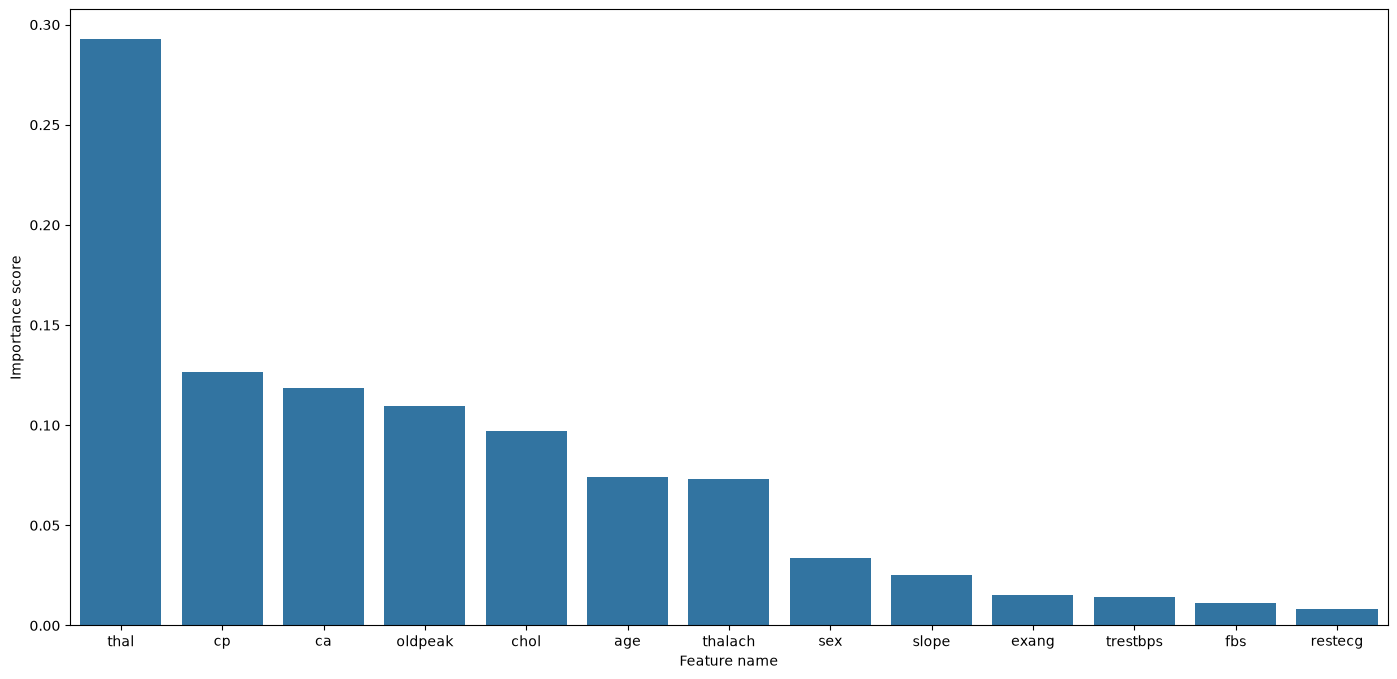

In [7]:
plt.figure(figsize=(17, 8))

sns.barplot(data=feature_importance_series)
plt.xlabel("Feature name")
plt.ylabel("Importance score")



In [8]:
selected_features = feature_importance_series.head(K_FEATURE).index.tolist()
print(f"Top {K_FEATURE} selected features:")
print(selected_features)


Top 10 selected features:
['thal', 'cp', 'ca', 'oldpeak', 'chol', 'age', 'thalach', 'sex', 'slope', 'exang']


In [9]:
#import new dataframe
train_df = pd.read_csv('../data/processed/train_cleaned.csv')
test_df = pd.read_csv('../data/processed/test_cleaned.csv')

X_train, y_train = train_df.drop(columns='target'), train_df['target']
X_test, y_test = test_df.drop(columns='target'), test_df['target']

X_train_sel = X_train[selected_features]

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
scores = cross_validate(
    dt_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

dt_topk_result = pd.DataFrame([{
    "Model": "Decision Tree + Top-10",
    "Accuracy": scores["test_accuracy"].mean(),
    "Precision": scores["test_precision"].mean(),
    "Recall": scores["test_recall"].mean(),
    "F1": scores["test_f1"].mean(),
    "ROC-AUC": scores["test_roc_auc"].mean(),
    "F1 Std": scores["test_f1"].std()
}])

dt_topk_result

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Std
0,Decision Tree + Top-10,0.706122,0.680475,0.702372,0.688863,0.705887,0.050057
